# Vertical integration: RNA + ADT + ATAC, every method

This notebook runs every method that has a variant for vertical RNA + ADT + ATAC on `D22mini`: MOFA2, Matilda, Multigrate, UINMF and scMoMaT. The [tutorial](https://dsichang.github.io/scMultiBench/tutorials/vertical_rna_adt_atac/) explains each step and runs Matilda and UINMF only.

Methods run on Linux. The environments are 5 envs, 16.4 GB to download on a CPU host, 22.5 GB on a GPU host.

## 1. Install

This cell installs `multibench-sc`. It keeps the numpy and pandas that are already installed, so Colab needs no restart.

<details>
<summary>Details</summary>

On Colab, choose a GPU runtime before you run the notebook: Runtime -> Change runtime type -> T4 GPU. On a CPU runtime, an environment that has a smaller CPU build gets that build, and training methods run slower.

</details>

In [1]:
import numpy, pandas
%pip install -q multibench-sc numpy=={numpy.__version__} pandas=={pandas.__version__}

Note: you may need to restart the kernel to use updated packages.


## 2. Download the data and the environments

In [2]:
import pandas as pd
import multibench as mtb

mtb.data.fetch("D22mini")

PosixPath('/tmp/mbverify/home/.cache/multibench/data')

In [3]:
METHODS = ["MOFA2", "Matilda", "Multigrate", "UINMF", "scMoMaT"]
envs = mtb.env.install(METHODS, dry_run=False)
pd.DataFrame(envs)[["env", "methods", "state"]]

,env,methods,state
0,MOFA2_env,[MOFA2],have
1,matilda,[Matilda],have
2,scmb_multigrate2,[Multigrate],have
3,scmb_r,[UINMF],have
4,scmb_torch,[scMoMaT],have


## 3. Run the methods

In [4]:
res = mtb.run_all("D22mini", "vertical", methods=METHODS,
                  out_dir="out/D22mini_all")
res.summary

[run_all] MOFA2 runs on rna+adt+atac, not on rna+adt and rna+atac, whose files are part of it. Pass modalities= to run a smaller combination.


[run_all] Matilda runs on rna+adt+atac, not on rna+adt and rna+atac, whose files are part of it. Pass modalities= to run a smaller combination.


[run_all] Multigrate runs on rna+adt+atac, not on rna+adt and rna+atac, whose files are part of it. Pass modalities= to run a smaller combination.


[run_all] UINMF runs on rna+adt+atac, not on rna+adt and rna+atac, whose files are part of it. Pass modalities= to run a smaller combination.


[run_all] scMoMaT runs on rna+adt+atac, not on rna+adt and rna+atac, whose files are part of it. Pass modalities= to run a smaller combination.


...

[run_all] UINMF (vertical/D22mini) ...


[run_all]   -> CHAIN_OK (19.5s) ARI 0.814


[run_all] scMoMaT (vertical/D22mini) ...


[run_all]   -> CHAIN_OK_GRAPH_METHOD (63.5s) ARI 0.213


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,batch_source,n_batches,ARI,NMI,ASW,iASW,iF1,cLISI,label_order_note,caveat,reason
0,MOFA2,CHAIN_OK,40.3,embedding,"[3000, 18]",0,cty.csv,NaN,None,1,0.2794,0.5564,0.5194,0.5004,0.5591,0.9809,single ordering,,
1,Matilda,CHAIN_OK,15.6,embedding,"[3000, 100]",10,cty.csv,NaN,None,1,0.8855,0.8645,0.6226,0.6466,0.7851,0.9922,single ordering,,
2,Multigrate,CHAIN_OK,47.7,embedding,"[3000, 15]",3,cty.csv,NaN,None,1,0.2874,0.5810,0.5226,0.4955,0.4924,0.9825,single ordering,,
3,UINMF,CHAIN_OK,19.5,embedding,"[3000, 30]",0,cty.csv,NaN,None,1,0.8141,0.7824,0.6087,0.5737,0.6146,0.9952,single ordering,,
4,scMoMaT,CHAIN_OK_GRAPH_METHOD,63.5,graph,"[3000, 2]",0,cty.csv,NaN,None,1,0.2126,0.4788,0.4830,0.4520,0.4483,0.9742,single ordering,,


## 4. Plot

`res.plot()` draws the scores as a bubble table. Circle size shows the rank within a column, and bigger is better. The fill compares a value with the other rows in the same column.

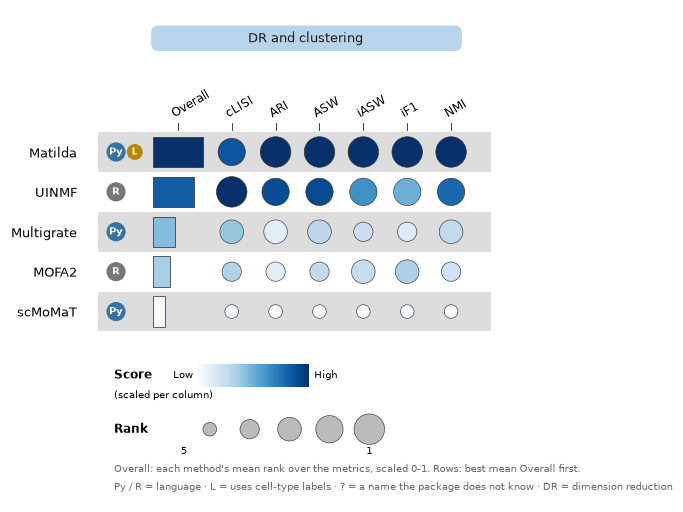

In [5]:
res.plot()